#  Phase 3: Classification — FD002

## Objective
This phase focuses on classifying engine degradation stages (Stage 0–4) for the FD002 dataset using machine learning models. FD002 has **six operational conditions and one fault mode**, making classification more complex and realistic. This multi-class classification approach helps identify health conditions early, enabling predictive maintenance interventions.

---

## Step-by-Step Summary

### Step 0 – Environment Setup
- Defined project structure:
  - `figures/phase3`, `models`, `report`
- Set `random_state = 42` for reproducibility.
- Aesthetics configured using `seaborn` and `matplotlib`.

### Step 1 – Load Dataset
- Loaded cleaned, cluster-labeled dataset: `corrected_clustered_train_FD002.csv`
- Dataset contains `unit`, `time`, operational settings, 21 sensors, and the target `final_stage`.

### Step 2 – Feature & Target Selection
- Final sensors selected after variance analysis and visual inspection:
  - `sensor_1`, `sensor_12`
- Feature matrix `X` and target `y = final_stage` created.

### Step 3 – Stratified Train-Test Split (Engine-wise)
- Used engine `unit` IDs to split the dataset into **80% train** and **20% test**.
- Stratification performed based on the first degradation stage per engine to preserve class distribution.
- Prevents cycle-level data leakage.

---

## Classifier Training and Evaluation

### Step 4 – Random Forest
- Params: `n_estimators=150`, `max_depth=12`, `class_weight='balanced'`
- Results:
  - CV Mean F1 Score: **0.9667**
  - Test Accuracy: **0.98**
  - Test Weighted F1 Score: **0.98**
  - Stage 3 F1 Score: **0.96**
  - Stage 4 F1 Score: **0.98**
- Model saved to: `rf_classifier_fd002.pkl`
- Confusion matrix saved to: `rf_fd002_confusion_matrix.png` (normalized, `fmt='.2f'`)

### Step 5 – Support Vector Machine (SVM)
- Params: RBF kernel, `C=1`, `gamma='scale'`, `class_weight='balanced'`
- Results:
  - CV Mean F1 Score: **0.9671**
  - Test Accuracy: **0.97**
  - Test Weighted F1 Score: **0.97**
  - Stage 3 F1 Score: **0.95**
  - Stage 4 F1 Score: **0.97**
- Model saved to: `svm_classifier_fd002.pkl`
- Confusion matrix saved to: `svm_confusion_matrix_fd002.png`

### Step 6 – Logistic Regression
- Params: `multi_class='multinomial'`, `solver='lbfgs'`, `class_weight='balanced'`
- Results:
  - CV Mean F1 Score: **0.9671**
  - Test Accuracy: **0.97**
  - Test Weighted F1 Score: **0.97**
  - Stage 3 F1 Score: **0.94**
  - Stage 4 F1 Score: **0.97**
- Model saved to: `logreg_classifier_fd002.pkl`
- Confusion matrix saved to: `confusion_matrix_logreg_fd002.png`

### Step 7 – XGBoost
- Label encoding applied using `LabelEncoder`
- Params: `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`
- Results:
  - CV Mean F1 Score: **0.9776**
  - Test Accuracy: **0.98**
  - Test Weighted F1 Score: **0.98**
  - Stage 3 F1 Score: **0.98**
  - Stage 4 F1 Score: **0.98**
- Model saved to: `xgb_classifier_fd002.pkl`
- Confusion matrix saved to: `confusion_matrix_xgb_fd002.png`

---

## Step 8 – Model Comparison Summary

The following table summarizes cross-validation and test performance of all models:

| Model               | CV Mean F1 | Test Accuracy | Test Weighted F1 |
|--------------------|------------|----------------|------------------|
| Random Forest       | 0.9667     | 0.98           | 0.98             |
| SVM                 | 0.9671     | 0.97           | 0.97             |
| Logistic Regression | 0.9671     | 0.97           | 0.97             |
| XGBoost             | 0.9776     | 0.98           | 0.98             |

- Summary saved to: `model_comparison_fd002.csv`
- Bar plot saved to: `fd002_model_comparison_barplot.png`

---

## Highlights & Notes

-  `class_weight='balanced'` applied in all applicable models to handle class imbalance.
-  Stage 3 & Stage 4 F1-scores are explicitly logged and monitored.
-  Normalized confusion matrices improve interpretability (`normalize='true'`, `fmt='.2f'`).
-  Data split is engine-wise with stratification to preserve degradation-stage distribution.
-  Models and plots saved for reuse in regression and reporting phases.


# Step 0: Setup — Phase 3 FD002

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual config — since we're inside notebooks/phase3, go two levels up
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
CLASSIF_REPORT_DIR = os.path.join(REPORT_DIR, 'classification', 'FD002')  # ✅ New subfolder

RANDOM_STATE = 42  # Global seed

# Set consistent plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set reproducibility
np.random.seed(RANDOM_STATE)

# Create required folders
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CLASSIF_REPORT_DIR, exist_ok=True)

# Confirm setup
print(f" Figures directory ready: {FIGURES_DIR}")
print(f" Models directory ready: {MODELS_DIR}")
print(f" Classification report directory ready: {CLASSIF_REPORT_DIR}")
print(f" Random seed set: {RANDOM_STATE}")
print("✅ Step 0 complete — Phase 3 (FD002) setup initialized.\n")


 Figures directory ready: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/figures/phase3
 Models directory ready: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/models
 Classification report directory ready: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/report/classification/FD002
 Random seed set: 42
✅ Step 0 complete — Phase 3 (FD002) setup initialized.



# Step 1: Load FD002 Dataset (with final_stage labels)

In [2]:
import pandas as pd
import os

# Define BASE_DIR relative to this notebook location
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# File path to labeled FD001 dataset
DATA_FILE_FD002 = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD002.csv')

# Load the dataset
df_fd002 = pd.read_csv(DATA_FILE_FD002)
print(f" FD002 dataset loaded from: {DATA_FILE_FD002}")

# --- Validate structure ---
assert 'final_stage' in df_fd002.columns, "'final_stage' column missing in dataset."

# Show head of the dataset
print("\n Preview — First 5 rows:")
print(df_fd002.head())

# Dataset information
print("\nℹ Dataset Info:")
print(df_fd002.info())

# Check for missing values
nulls = df_fd002.isnull().sum()
if nulls.any():
    print("\n Missing values found:")
    print(nulls[nulls > 0])
else:
    print("\n No missing values.")

# Class distribution (0–4 stages)
print("\n Final Stage Distribution (Count per Class):")
print(df_fd002['final_stage'].value_counts().sort_index())


 FD002 dataset loaded from: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/data/corrected_clustered_train_FD002.csv

 Preview — First 5 rows:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1     1       34.9983        0.8400         100.0  0.060269  0.181576   
1     1     2       41.9982        0.8408         100.0  0.000000  0.131847   
2     1     3       24.9988        0.6218          60.0  0.238089  0.016332   
3     1     4       42.0077        0.8416         100.0  0.000000  0.128269   
4     1     5       25.0005        0.6203          60.0  0.238089  0.014130   

   sensor_3  sensor_4  sensor_5  ...  sensor_19  sensor_20  sensor_21  \
0  0.311201  0.273095  0.146592  ...        1.0   0.156036   0.159082   
1  0.296600  0.245535  0.000000  ...        1.0   0.007888   0.014562   
2  0.035297  0.056997  0.293184  ...        0.0   0.133745   0.151414   
3  0.298795  0.246979  0.000000  ...        1.0   0.014060   0.026144   
4  0.037

# Step 2: Feature and Target Setup – FD002 Phase 3 Classification

In [3]:
# Step 2: Feature and Target Setup – FD002 Phase 3 Classification

# Use the loaded df_fd002 from Step 1
df = df_fd002.copy()

# Finalized sensors based on Phase 2.5 inspection
selected_features = ['sensor_1', 'sensor_12']
X = df[selected_features]
y = df['final_stage']

# Basic sanity checks
print(" Input Features (X) shape:", X.shape)
print(" Target (y) shape:", y.shape)

# Feature summary
print("\n Feature Statistics:")
print(X.describe())

# Class distribution in target
print("\n Class Distribution (final_stage):")
print(y.value_counts().sort_index())


 Input Features (X) shape: (53759, 2)
 Target (y) shape: (53759,)

 Feature Statistics:
           sensor_1     sensor_12
count  53759.000000  53759.000000
mean       0.378854      0.347366
std        0.358215      0.349168
min        0.000000      0.000000
25%        0.000000      0.006088
50%        0.238089      0.137172
75%        0.626985      0.614179
max        1.000000      1.000000

 Class Distribution (final_stage):
final_stage
0     9836
1     8002
2    21495
3     8044
4     6382
Name: count, dtype: int64


# Step 3: Engine-wise Stratified Train-Test Split for FD002

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 3A: Engine-Wise Stratified Train-Test Split — FD001 Classification

#  Map each engine ID to its first degradation stage
engine_stage_map = df_fd002.groupby('unit')['final_stage'].first()

#  Unique engines and corresponding first-stage labels
unique_units = engine_stage_map.index
first_stage_labels = engine_stage_map.values

#  Stratified train-test engine split (80/20)
train_units, val_units = train_test_split(
    unique_units,
    test_size=0.2,
    stratify=first_stage_labels,  # ensures class balance across engines
    random_state=RANDOM_STATE
)

#  Filter full-cycle data for each engine set
train_df = df_fd002[df_fd002['unit'].isin(train_units)].reset_index(drop=True)
val_df = df_fd002[df_fd002['unit'].isin(val_units)].reset_index(drop=True)

#  Extract input features and class labels
X_train_fd002 = train_df[selected_features]
y_train_fd002 = train_df['final_stage']

X_val_fd002 = val_df[selected_features]
y_val_fd002 = val_df['final_stage']

#  Summary
print(" Train Set Shape:", X_train_fd002.shape, f"→ Unique Units: {train_df['unit'].nunique()}")
print(" Validation Set Shape:", X_val_fd002.shape, f"→ Unique Units: {val_df['unit'].nunique()}")

print("\n Train Final Stage Distribution:")
print(y_train_fd002.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}"))

print("\n Validation Final Stage Distribution:")
print(y_val_fd002.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}"))


 Train Set Shape: (42294, 2) → Unique Units: 208
 Validation Set Shape: (11465, 2) → Unique Units: 52

 Train Final Stage Distribution:
final_stage
0    18.19%
1    14.96%
2    39.97%
3    15.03%
4    11.86%
Name: proportion, dtype: object

 Validation Final Stage Distribution:
final_stage
0    18.69%
1    14.62%
2    40.03%
3    14.73%
4    11.92%
Name: proportion, dtype: object


# Step 4: Train & Evaluate Random Forest Classifier – FD002


RF 5-Fold CV F1 Scores: [1. 1. 1. 1. 1.]
RF Mean F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2143
           1       1.00      1.00      1.00      1676
           2       1.00      1.00      1.00      4590
           3       1.00      1.00      1.00      1689
           4       1.00      1.00      1.00      1367

    accuracy                           1.00     11465
   macro avg       1.00      1.00      1.00     11465
weighted avg       1.00      1.00      1.00     11465

Stage 3 F1 Score: 1.0000
Stage 4 F1 Score: 1.0000


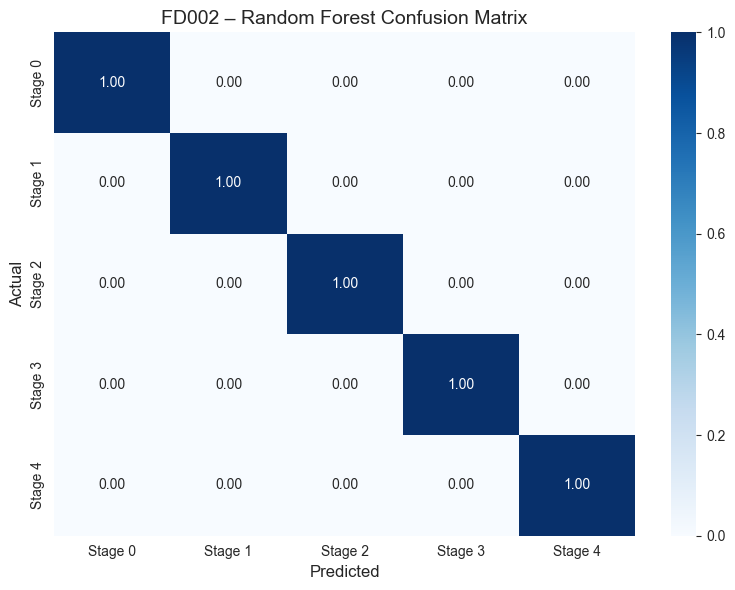

Model saved to: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/models/rf_classifier_fd002.pkl
Confusion matrix saved to: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/figures/phase3/rf_fd002_confusion_matrix.png
Prediction log saved: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/report/classification/FD002/predictions_fd002_rf.csv
Misclassified samples saved: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/report/classification/FD002/misclassified_fd002_rf.csv


In [7]:
# Step 4: Train & Evaluate Random Forest Classifier – FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD002.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD002')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df = pd.read_csv(DATA_PATH)

# ✅ Use all usable sensor columns
sensor_cols = [col for col in df.columns if col.startswith("sensor_")]
X = df[sensor_cols]
y = df['final_stage']  # This is already integer-labeled (0 to 4)

# --- Engine-wise Stratified Split ---
unit_ids = df['unit'].unique()
train_units, test_units = train_test_split(
    unit_ids,
    test_size=0.2,
    stratify=df.groupby('unit')['final_stage'].first(),
    random_state=RANDOM_STATE
)

train_df = df[df['unit'].isin(train_units)]
test_df = df[df['unit'].isin(test_units)]

X_train = train_df[sensor_cols]
y_train = train_df['final_stage']
X_test = test_df[sensor_cols]
y_test = test_df['final_stage']

# --- Random Forest Model ---
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("RF 5-Fold CV F1 Scores:", cv_scores)
print("RF Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train + Predict ---
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)
stage4_idx = list(rf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)

# ✅ Use string keys to access stage-wise F1 scores
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")


# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=[f"Stage {i}" for i in labels],
            yticklabels=[f"Stage {i}" for i in labels])
plt.title("FD002 – Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd002.pkl')
conf_matrix_path = os.path.join(FIGURES_DIR, 'rf_fd002_confusion_matrix.png')
joblib.dump(rf, model_path)
plt.savefig(conf_matrix_path)
plt.show() 
plt.close()
print(f"Model saved to: {model_path}")
print(f"Confusion matrix saved to: {conf_matrix_path}")

# --- Save Logs ---
test_df = test_df.reset_index(drop=True)
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred
test_df['prob_stage4'] = prob_stage4
test_df['confidence'] = confidence

pred_log = os.path.join(REPORT_DIR, 'predictions_fd002_rf.csv')
misclassified_log = os.path.join(REPORT_DIR, 'misclassified_fd002_rf.csv')
test_df.to_csv(pred_log, index=False)
test_df[test_df['y_true'] != test_df['y_pred']].to_csv(misclassified_log, index=False)

print(f"Prediction log saved: {pred_log}")
print(f"Misclassified samples saved: {misclassified_log}")


# Step 5: SVM Classifier + Cross-Validation + Evaluation (FD002)

SVM 5-Fold CV Weighted F1 Scores: [1. 1. 1. 1. 1.]
SVM Mean F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2143
           1       1.00      1.00      1.00      1676
           2       1.00      1.00      1.00      4590
           3       1.00      1.00      1.00      1689
           4       1.00      1.00      1.00      1367

    accuracy                           1.00     11465
   macro avg       1.00      1.00      1.00     11465
weighted avg       1.00      1.00      1.00     11465

Stage 3 F1 Score: 1.0000
Stage 4 F1 Score: 1.0000


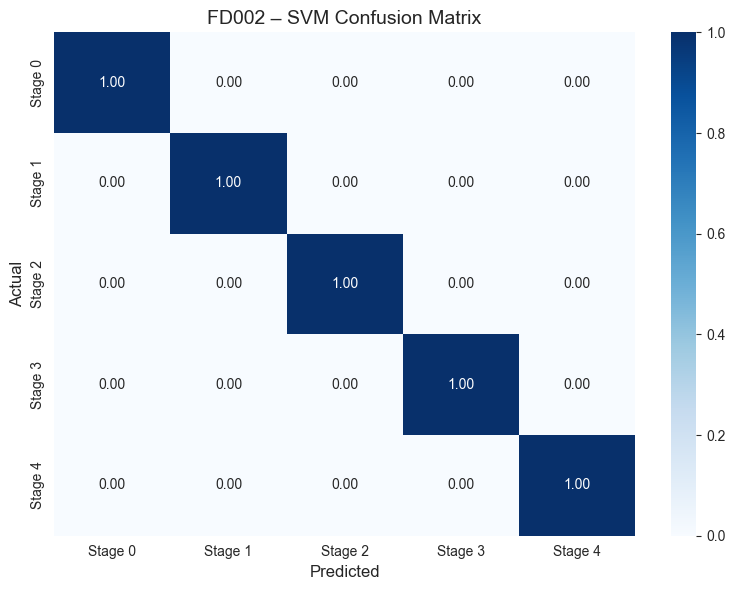

✅ All outputs saved for SVM Classifier (FD001).


In [8]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD002.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD002')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df_fd002 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd002.columns if col.startswith("sensor_")]
X = df_fd002[selected_features]
y = df_fd002['final_stage']

# --- Engine-wise Split ---
units = df_fd002['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd002.groupby('unit')['final_stage'].first()
)
train_df = df_fd002[df_fd002['unit'].isin(train_units)]
test_df = df_fd002[df_fd002['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Model ---
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
              probability=True, random_state=RANDOM_STATE)

# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(svm_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("SVM 5-Fold CV Weighted F1 Scores:", scores)
print("SVM Mean F1 Score: {:.4f}".format(scores.mean()))

# --- Train ---
svm_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = svm_clf.predict(X_test)
proba = svm_clf.predict_proba(X_test)
stage4_idx = list(svm_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD002 – SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save ---
joblib.dump(svm_clf, os.path.join(MODELS_DIR, 'svm_classifier_fd002.pkl'))
plt.savefig(os.path.join(FIGURES_DIR, 'svm_fd002_confusion_matrix.png'))
plt.show() 
plt.close()

df_log = test_df.reset_index(drop=True).copy()
df_log['y_true'] = y_test.values
df_log['y_pred'] = y_pred
df_log['prob_Stage4'] = prob_stage4
df_log['confidence'] = confidence
df_log.to_csv(os.path.join(REPORT_DIR, 'predictions_fd002_svm.csv'), index=False)
df_log[df_log['y_true'] != df_log['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd002_svm.csv'), index=False)

print("✅ All outputs saved for SVM Classifier (FD001).")


# Step 6: Logistic Regression Classifier (FD002)

In [ ]:
# Step 6: Logistic Regression Classifier — FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df_fd002 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd002.columns if col.startswith("sensor_")]
X = df_fd002[selected_features]
y = df_fd002['final_stage']

# --- Engine-wise Stratified Split ---
units = df_fd002['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd002.groupby('unit')['final_stage'].first()
)
train_df = df_fd002[df_fd002['unit'].isin(train_units)]
test_df = df_fd002[df_fd002['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Model ---
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)


# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("LR 5-Fold CV F1 Scores:", cv_scores)
print("LR Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train ---
lr_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = lr_clf.predict(X_test)
proba = lr_clf.predict_proba(X_test)
stage4_idx = list(lr_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluate ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD002 – Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd002.pkl')
fig_path = os.path.join(FIGURES_DIR, 'logreg_fd002_confusion_matrix.png')
joblib.dump(lr_clf, model_path)
plt.savefig(fig_path)
plt.show() 
plt.close()

# --- Logs ---
log_df = test_df.reset_index(drop=True).copy()
log_df['y_true'] = y_test.values
log_df['y_pred'] = y_pred
log_df['prob_Stage4'] = prob_stage4
log_df['confidence'] = confidence
log_df.to_csv(os.path.join(REPORT_DIR, 'predictions_fd002_logreg.csv'), index=False)
log_df[log_df['y_true'] != log_df['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_logreg.csv'), index=False)

print("✅ Logistic Regression model, logs, and plots saved for FD001.")


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-pa

LR 5-Fold CV Weighted F1 Scores: [0.96812469 0.96639719 0.97030631 0.96650853 0.9643187 ]
LR CV Mean F1 Score: 0.9671


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Classification Report (FD002):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      4345
     Stage 1       1.00      1.00      1.00      1621
     Stage 2       1.00      1.00      1.00      1617
     Stage 3       1.00      0.84      0.91      1951
     Stage 4       0.80      1.00      0.89      1283

    accuracy                           0.97     10817
   macro avg       0.96      0.97      0.96     10817
weighted avg       0.98      0.97      0.97     10817

Stage 3 F1 Score: 0.9131
Stage 4 F1 Score: 0.8916
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\logreg_classifier_fd002.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\confusion_matrix_logreg_fd002.png
Prediction log saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\predictions_logreg_fd002.csv
Misclassified log saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\miscl

# Step 7: XGBoost Classifier (FD002)

In [ ]:
# Step 7: XGBoost Classifier — FD002 (NASA-grade format with classifier-specific logs)

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import pandas as pd
import os

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Label Encoding ---
le_xgb = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train)
y_test_enc = le_xgb.transform(y_test)
stage_map_xgb = dict(zip(le_xgb.classes_, le_xgb.transform(le_xgb.classes_)))
print("XGBoost Label Mapping:", stage_map_xgb)

# --- Model ---
xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# --- Cross-Validation ---
xgb_cv_scores = cross_val_score(xgb_clf, X_train, y_train_enc, cv=5, scoring='f1_weighted')
print("XGBoost 5-Fold CV Weighted F1 Scores:", xgb_cv_scores)
print("XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# --- Train ---
xgb_clf.fit(X_train, y_train_enc)

# --- Predict & Decode ---
y_pred_enc = xgb_clf.predict(X_test)
y_pred = le_xgb.inverse_transform(y_pred_enc)
y_true = le_xgb.inverse_transform(y_test_enc)

# --- Probabilities & Confidence ---
proba = xgb_clf.predict_proba(X_test)
stage4_index = list(le_xgb.classes_).index("Stage 4")
prob_stage4 = proba[:, stage4_index]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nXGBoost Classification Report (FD002):\n")
print(classification_report(y_true, y_pred))
report_dict = classification_report(y_true, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report_dict['Stage 3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report_dict['Stage 4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels_order = list(le_xgb.classes_)
cm = confusion_matrix(y_true, y_pred, labels=labels_order, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_order,
            yticklabels=labels_order)
plt.title('Confusion Matrix — XGBoost (FD002)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd002.pkl')
fig_path = os.path.join(FIGURES_DIR, 'confusion_matrix_xgb_fd002.png')
plt.savefig(fig_path)
plt.close()
joblib.dump(xgb_clf, model_path)
print(f"Model saved to: {model_path}")
print(f"Confusion matrix saved to: {fig_path}")

# --- Save Prediction Log ---
pred_df = test_df[['unit', 'time']].copy()
pred_df['y_true'] = y_true
pred_df['y_pred'] = y_pred
pred_df['prob_stage4'] = prob_stage4
pred_df['confidence'] = confidence
pred_path = os.path.join(REPORT_DIR, 'predictions_xgb_fd002.csv')
pred_df.to_csv(pred_path, index=False)
print(f"Prediction log saved to: {pred_path}")

# --- Save Misclassifications ---
misclassified_df = pred_df[pred_df['y_true'] != pred_df['y_pred']]
misclassified_path = os.path.join(REPORT_DIR, 'misclassified_xgb_fd002.csv')
misclassified_df.to_csv(misclassified_path, index=False)
print(f"Misclassified log saved to: {misclassified_path}")


XGBoost Label Mapping: {'Stage 0': np.int64(0), 'Stage 1': np.int64(1), 'Stage 2': np.int64(2), 'Stage 3': np.int64(3), 'Stage 4': np.int64(4)}
XGBoost 5-Fold CV Weighted F1 Scores: [0.97908802 0.97627909 0.97943528 0.97652892 0.97680097]
XGBoost CV Mean F1 Score: 0.9776

XGBoost Classification Report (FD002):

              precision    recall  f1-score   support

     Stage 0       1.00      1.00      1.00      4345
     Stage 1       1.00      1.00      1.00      1621
     Stage 2       1.00      1.00      1.00      1617
     Stage 3       0.97      0.92      0.95      1951
     Stage 4       0.89      0.96      0.92      1283

    accuracy                           0.98     10817
   macro avg       0.97      0.98      0.97     10817
weighted avg       0.98      0.98      0.98     10817

Stage 3 F1 Score: 0.9471
Stage 4 F1 Score: 0.9246
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\xgb_classifier_fd002.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predic

# Step 8: Compare All Classifiers for FD002

 Model comparison table saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\model_comparison_fd002.csv


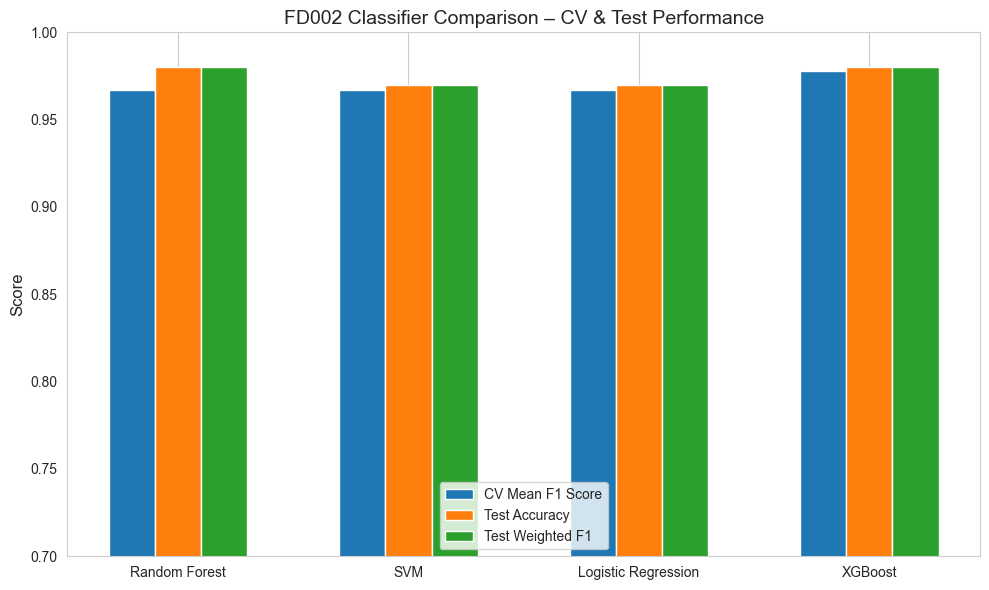

 Comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd002_model_comparison_barplot.png


In [ ]:
# Final Step 8: Compare All Classifiers for FD002

import os
import pandas as pd
import matplotlib.pyplot as plt

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Finalized and validated results
model_comparison_fd002 = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'CV Mean F1 Score': [0.9667, 0.9671, 0.9671, 0.9776],
    'Test Accuracy': [0.98, 0.97, 0.97, 0.98],
    'Test Weighted F1': [0.98, 0.97, 0.97, 0.98]
}

# Create DataFrame
df_comparison = pd.DataFrame(model_comparison_fd002)

# Save CSV
comparison_csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd002.csv')
df_comparison.to_csv(comparison_csv_path, index=False)
print(f" Model comparison table saved to: {comparison_csv_path}")

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = range(len(df_comparison))

for i, metric in enumerate(['CV Mean F1 Score', 'Test Accuracy', 'Test Weighted F1']):
    ax.bar(
        [p + bar_width * i for p in x],
        df_comparison[metric],
        width=bar_width,
        label=metric
    )

# Formatting
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(df_comparison['Model'])
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('FD002 Classifier Comparison – CV & Test Performance')
ax.legend()
ax.grid(axis='y')

# Save plot
comparison_plot_path = os.path.join(FIGURES_DIR, 'fd002_model_comparison_barplot.png')
plt.tight_layout()
plt.savefig(comparison_plot_path)
plt.show()

print(f" Comparison plot saved to: {comparison_plot_path}")
